In [29]:
from uxsim import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [30]:
# Shared corridor definition (formal/informal) — single source of truth with simulation_extended.py
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.').resolve()))

from corridor_config import (
    TOTAL_LENGTH_M,
    FREE_FLOW_SPEED,
    NUM_LANES,
    TMAX,
    SIGNAL_POS,
    SESSION_DWELL,
    SESSIONS,
    SESSION_DEMAND,
    STOP_CONFIGS,
    HEADWAYS,
    ORIGINS,
    FORMAL_STOPS_FWD,
    INFORMAL_STOPS_FWD,
    FORMAL_STOPS_REV,
    INFORMAL_STOPS_REV,
    active_stops_for_config,
    print_corridor_legend,
)

# Survey legend (enforced in corridor_config.STOPS_*):
#   Formal:   Robinsons & Waltermart terminals, Vista Mall
#   Informal: 7-Eleven, Villa Verde, RCBC, curbside at Robinsons

total = len(SESSIONS) * len(ORIGINS) * len(STOP_CONFIGS) * len(HEADWAYS)
print('Parameters loaded from corridor_config.py')
print(f'Total combinations: {len(SESSIONS)} sessions × {len(ORIGINS)} origins × '
      f'{len(STOP_CONFIGS)} stop configs × {len(HEADWAYS)} headways = {total} scenarios')
print()
print('Mid-route stop counts (positions only; dwell set per session in build_world):')
print(f'  Forward formal:   {list(FORMAL_STOPS_FWD.keys())}')
print(f'  Forward informal: {list(INFORMAL_STOPS_FWD.keys())}')
print(f'  Reverse formal:   {list(FORMAL_STOPS_REV.keys())}')
print(f'  Reverse informal: {list(INFORMAL_STOPS_REV.keys())}')
print(f'  Signal @ {SIGNAL_POS}m')
print()
print_corridor_legend()
print()
print('Session terminal dwell means (field):')
for sess, d in SESSION_DWELL.items():
    print(f'  {sess:20s}: Robinsons={d["robinsons"]}s, Waltermart={d["waltermart"]}s')

Parameters loaded.
Total combinations: 3 sessions × 2 origins × 5 stop configs × 4 headways = 120 scenarios

Stop layout summary:
  Forward (Rob→Wal): 3 formal stops + 2 informal stops
  Reverse (Wal→Rob): 2 formal stops + 1 informal stop
  Signal intersection at 2495m from Robinsons

Session dwell times (informal, from field data):
  Morning Session     : Robinsons=46.6s, Waltermart=35.1s
  Lunch               : Robinsons=59.4s, Waltermart=35.0s
  Afternoon Session   : Robinsons=52.3s, Waltermart=41.3s


In [31]:
def build_world(scenario_id, session, origin, stop_cfg, hw_val, seed=42):
    """
    Builds the Dasmariñas corridor in UXsim.

    Corridor: Robinsons Pala-Pala ↔ Waltermart Dasmariñas (3,049 m)

    Formal (survey legend): Robinsons & Waltermart terminals, Vista Mall.
    Informal: 7-Eleven, Villa Verde, RCBC, curbside at Robinsons.
    See corridor_config.print_corridor_legend() for chainage.
    Dwell per stop comes from active_stops_for_config(session, stop_cfg).
    """
    dwell_scale = float(stop_cfg['dwell_scale'])

    # Active stops + session dwells from corridor_config (same rules as simulation_extended.py)
    active_fwd, active_rev = active_stops_for_config(session, stop_cfg)
    sorted_fwd = sorted(active_fwd.items(), key=lambda x: x[1]['pos'])
    sorted_rev = sorted(active_rev.items(), key=lambda x: x[1]['pos'])

    # ── BUILD WORLD ──────────────────────────────────────────────────────
    W = World(
        name=scenario_id,
        deltan=5,
        tmax=TMAX,
        print_mode=0,
        save_mode=0,
        show_mode=0,
        random_seed=seed
    )

    # ── FORWARD NODE CHAIN: Robinsons → Waltermart ───────────────────────
    fwd_chain = [('Robinsons', 0)]
    for name, info in sorted_fwd:
        fwd_chain.append((name, info['pos']))
    fwd_chain.append(('Signal_Node', SIGNAL_POS))
    fwd_chain.append(('Waltermart', TOTAL_LENGTH_M))

    # Remove duplicate positions (safety check)
    seen = set()
    clean = []
    for name, pos in fwd_chain:
        if pos not in seen:
            clean.append((name, pos))
            seen.add(pos)
    fwd_chain = sorted(clean, key=lambda x: x[1])

    # ── REVERSE NODE CHAIN: Waltermart → Robinsons ───────────────────────
    # Positions expressed as distance FROM Waltermart
    rev_chain = [('Waltermart', 0)]
    for name, info in sorted_rev:
        rev_chain.append((name + '_R', info['pos']))  # _R suffix avoids node name clash
    rev_chain.append(('Robinsons', TOTAL_LENGTH_M))

    seen_r = set()
    clean_r = []
    for name, pos in rev_chain:
        if pos not in seen_r:
            clean_r.append((name, pos))
            seen_r.add(pos)
    rev_chain = sorted(clean_r, key=lambda x: x[1])

    # ── ADD ALL NODES ────────────────────────────────────────────────────
    all_node_names = set()
    for name, pos in fwd_chain + rev_chain:
        if name not in all_node_names:
            x = round(pos / 1000, 4)
            if name == 'Signal_Node':
                W.addNode(name, x, 0, signal=[45, 45])  # 90s cycle, 45s per phase
            else:
                W.addNode(name, x, 0)
            all_node_names.add(name)

    # ── ADD FORWARD LINKS ────────────────────────────────────────────────
    for i in range(len(fwd_chain) - 1):
        from_name, from_pos = fwd_chain[i]
        to_name,   to_pos   = fwd_chain[i + 1]
        seg_len = to_pos - from_pos
        if seg_len <= 0:
            continue

        # If arriving at a stop node, bake dwell into effective speed
        if to_name in active_fwd:
            dwell_t   = active_fwd[to_name]['dwell']
            free_t    = seg_len / FREE_FLOW_SPEED
            eff_speed = seg_len / (free_t + dwell_t)
            eff_speed = max(eff_speed, 2.5)
        else:
            eff_speed = FREE_FLOW_SPEED

        W.addLink(
            f'fwd_{from_name}_to_{to_name}',
            from_name, to_name,
            length=seg_len,
            free_flow_speed=eff_speed,
            number_of_lanes=NUM_LANES,
            jam_density=0.2,
        )

    # ── ADD REVERSE LINKS ────────────────────────────────────────────────
    for i in range(len(rev_chain) - 1):
        from_name, from_pos = rev_chain[i]
        to_name,   to_pos   = rev_chain[i + 1]
        seg_len = to_pos - from_pos
        if seg_len <= 0:
            continue

        # Check if arriving node is a reverse stop
        rev_stop_key = to_name.replace('_R', '') if to_name.endswith('_R') else to_name
        if to_name in [n + '_R' for n in active_rev]:
            base_key  = to_name[:-2]  # strip _R
            dwell_t   = active_rev[base_key]['dwell']
            free_t    = seg_len / FREE_FLOW_SPEED
            eff_speed = seg_len / (free_t + dwell_t)
            eff_speed = max(eff_speed, 2.5)
        else:
            eff_speed = FREE_FLOW_SPEED

        W.addLink(
            f'rev_{from_name}_to_{to_name}',
            from_name, to_name,
            length=seg_len,
            free_flow_speed=eff_speed,
            number_of_lanes=NUM_LANES,
            jam_density=0.2,
        )

    # ── BUS DEMAND ───────────────────────────────────────────────────────
    bus_flow = SESSION_DEMAND[session]['bus']
    if hw_val is not None:
        bus_flow = 1 / hw_val

    # Forward buses (Robinsons → Waltermart)
    W.adddemand('Robinsons', 'Waltermart', 0, TMAX, bus_flow)
    # Reverse buses (Waltermart → Robinsons) — ~60% of forward volume
    W.adddemand('Waltermart', 'Robinsons', 0, TMAX, bus_flow * 0.6)

    # ── RANDOMIZED OTHER VEHICLES (cars + jeepneys) ──────────────────────
    rng = np.random.default_rng(seed)
    car_base     = SESSION_DEMAND[session]['car']
    jeepney_base = SESSION_DEMAND[session]['jeepney']

    # Cars: 3 time windows with random variation
    for t_start, t_end, peak_mult in [(0, 1200, 0.8), (1200, 2400, 1.3), (2400, 3600, 1.0)]:
        car_flow = car_base * peak_mult * rng.uniform(0.7, 1.3)
        W.adddemand('Robinsons', 'Waltermart', t_start, t_end, car_flow)
        W.adddemand('Waltermart', 'Robinsons', t_start, t_end, car_flow * rng.uniform(0.5, 0.8))

    # Jeepneys: short partial trips between interior nodes
    interior_fwd = [n for n, _ in fwd_chain
                    if n not in ('Robinsons', 'Waltermart', 'Signal_Node')]
    if interior_fwd:
        jeepney_flow = jeepney_base * rng.uniform(0.8, 1.2)
        mid = rng.choice(interior_fwd)
        W.adddemand('Robinsons', mid,          0, TMAX, jeepney_flow)
        W.adddemand(mid,         'Waltermart', 0, TMAX, jeepney_flow * 0.5)

    return W

print('World builder function ready (uses corridor_config stop legend).')
print_corridor_legend()

World builder function ready.

Forward stop positions (Robinsons → Waltermart):
  0m      — Robinsons terminal (origin)
  50m     — Informal: In front of Robinsons [pre-signal]
  200m    — Formal F1: 7-Eleven Pala Pala
  1845m   — Formal F2: Villa Verde
  2083m   — Formal F3: Vista Mall
  2495m   — Signal intersection (45s/45s cycle)
  2884m   — Informal: RCBC Bank [post-signal]
  3049m   — Waltermart terminal (Formal F4 / destination)

Reverse stop positions (Waltermart → Robinsons):
  0m      — Waltermart terminal (origin)
  165m    — Informal: RCBC Bank
  966m    — Formal: Vista Mall
  1203m   — Formal: Villa Verde
  3049m   — Robinsons terminal (destination)


In [32]:
results = []
errors  = []

all_combos = list(itertools.product(
    SESSIONS,
    ORIGINS,
    STOP_CONFIGS.items(),
    HEADWAYS.items()
))

print(f'Starting {len(all_combos)} scenarios...\n')

# Compute per-session baseline travel times for improvement % calculation
# Key: (session, origin, headway_label)
baseline_tt = {}

for idx, (session, origin, (stop_label, stop_cfg), (hw_label, hw_val)) in enumerate(all_combos):

    seed        = 100 + idx
    orig_short  = 'rob' if 'robinsons' in origin else 'wal'
    sess_short  = session[:3]
    scenario_id = f'S{idx+1:03d}__{sess_short}__{orig_short}__{stop_label}__{hw_label}'

    print(f'[{idx+1:3d}/{len(all_combos)}] {scenario_id}', end=' ... ')

    try:
        W = build_world(scenario_id, session, origin, stop_cfg, hw_val, seed=seed)
        W.exec_simulation()
        W.analyzer.basic_analysis()

        att   = W.analyzer.average_travel_time
        adel  = W.analyzer.average_delay
        dratio = adel / att if att > 0 else 0
        aspd  = W.analyzer.average_speed
        trips = W.analyzer.trip_completed

        # Store baseline travel time for improvement calculation
        bkey = (session, origin, hw_label)
        if stop_label == 'baseline_all_informal':
            baseline_tt[bkey] = att

        btt  = baseline_tt.get(bkey, att)
        tsaved = btt - att
        imp_pct = (tsaved / btt * 100) if btt > 0 else 0

        results.append({
            'scenario_index':  idx + 1,
            'scenario_id':     scenario_id,
            'session':         session,
            'data_origin':     origin,
            'stop_config':     stop_label,
            'headway':         hw_label,
            'headway_sec':     hw_val if hw_val else 'observed',
            'use_formal':      stop_cfg['use_formal'],
            'use_informal':    stop_cfg['use_informal'],
            'dwell_scale':     stop_cfg['dwell_scale'],
            'num_lanes':       NUM_LANES,
            'random_seed':     seed,
            'avg_travel_time': round(att,   2),
            'avg_delay':       round(adel,  2),
            'delay_ratio':     round(dratio, 4),
            'avg_speed':       round(aspd,  4),
            'completed_trips': trips,
            'baseline_tt':     round(btt,   2),
            'time_saved_s':    round(tsaved, 2),
            'improvement_pct': round(imp_pct, 2),
        })

        print(f'\u2713  TT={att:.1f}s  delay={adel:.1f}s  speed={aspd:.2f}m/s  trips={trips}')

    except Exception as e:
        errors.append({'scenario_id': scenario_id, 'error': str(e)})
        print(f'\u2717  ERROR: {e}')

print()
print('=' * 60)
print(f'Completed: {len(results)} | Errors: {len(errors)}')
print('=' * 60)

# Save results
df = pd.DataFrame(results)
df.to_csv('results_summary.csv', index=False)
print('\nSaved: results_summary.csv')

if errors:
    pd.DataFrame(errors).to_csv('results_errors.csv', index=False)
    print(f'Errors saved: results_errors.csv ({len(errors)} scenarios failed)')

Starting 120 scenarios...

[  1/120] S001__Mor__rob__baseline_all_informal__headway_observed ... ✓  TT=218.0s  delay=9.8s  speed=12.57m/s  trips=440
[  2/120] S002__Mor__rob__baseline_all_informal__headway_10min ... ✓  TT=201.0s  delay=12.0s  speed=12.36m/s  trips=435
[  3/120] S003__Mor__rob__baseline_all_informal__headway_15min ... ✓  TT=216.1s  delay=10.3s  speed=12.55m/s  trips=395
[  4/120] S004__Mor__rob__baseline_all_informal__headway_20min ... ✓  TT=220.7s  delay=12.0s  speed=12.44m/s  trips=340
[  5/120] S005__Mor__rob__baseline_mixed__headway_observed ... ✓  TT=247.6s  delay=12.9s  speed=10.03m/s  trips=405
[  6/120] S006__Mor__rob__baseline_mixed__headway_10min ... ✓  TT=231.0s  delay=8.9s  speed=10.24m/s  trips=360
[  7/120] S007__Mor__rob__baseline_mixed__headway_15min ... ✓  TT=243.1s  delay=5.5s  speed=10.32m/s  trips=365
[  8/120] S008__Mor__rob__baseline_mixed__headway_20min ... ✓  TT=241.7s  delay=8.0s  speed=10.32m/s  trips=365
[  9/120] S009__Mor__rob__optimized_for

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results_summary.csv')

print(f'Scenarios completed: {len(df)}')
print(f'\nBy stop config:')
print(df['stop_config'].value_counts())
print(f'\nBy session:')
print(df['session'].value_counts())
print(f'\nSample metrics:')
print(df[['avg_travel_time','avg_delay','avg_speed',
           'completed_trips','improvement_pct']].describe().round(2))

Scenarios completed: 120

By stop config:
stop_config
baseline_all_informal    24
baseline_mixed           24
optimized_formal_only    24
optimized_short_dwell    24
optimized_two_formal     24
Name: count, dtype: int64

By session:
session
Morning Session      40
Lunch                40
Afternoon Session    40
Name: count, dtype: int64

Sample metrics:
       avg_travel_time  avg_delay  avg_speed  completed_trips  improvement_pct
count           120.00     120.00     120.00           120.00           120.00
mean            211.06       8.67      12.30           315.71            -3.60
std              24.04       1.87       1.20            68.69            12.60
min             161.88       4.36       9.82           200.00           -40.54
25%             193.36       7.46      12.21           248.75            -9.41
50%             205.39       8.46      12.46           315.00             0.00
75%             220.70       9.59      13.15           370.00             4.16
max         

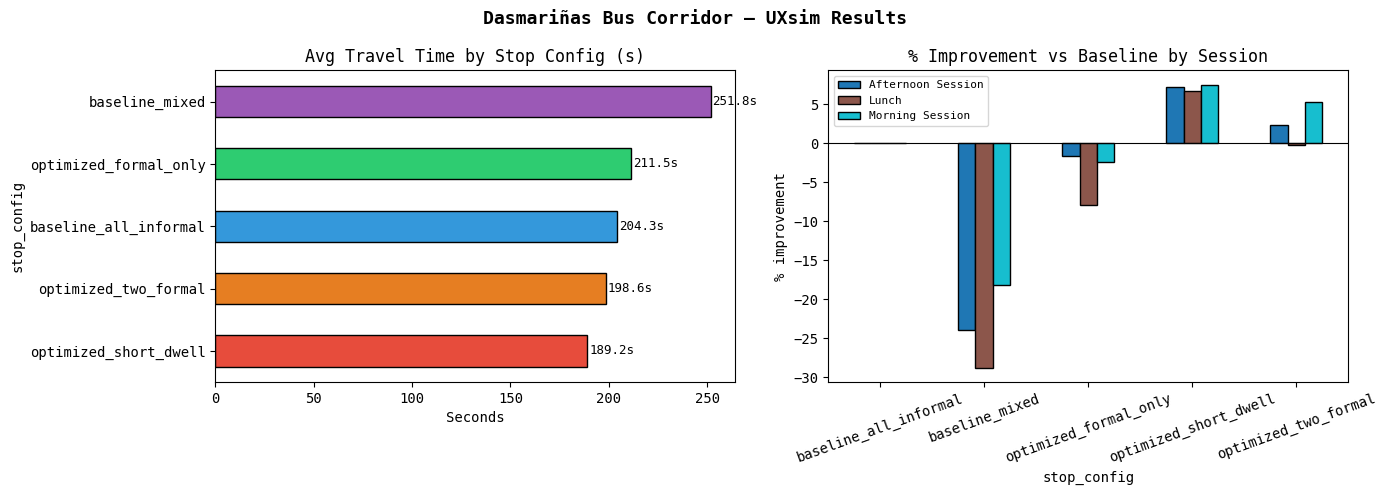

Plot saved: results_preview.png


In [35]:
df = pd.read_csv('results_summary.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dasmariñas Bus Corridor — UXsim Results', fontsize=13, fontweight='bold')

# Chart 1: Avg travel time by stop config
ax1 = axes[0]
grp = df.groupby('stop_config')['avg_travel_time'].mean().sort_values()
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']
grp.plot(kind='barh', ax=ax1, color=colors[:len(grp)], edgecolor='black')
ax1.set_title('Avg Travel Time by Stop Config (s)')
ax1.set_xlabel('Seconds')
for i, v in enumerate(grp):
    ax1.text(v + 1, i, f'{v:.1f}s', va='center', fontsize=9)

# Chart 2: % improvement by session
ax2 = axes[1]
pivot = df.groupby(['stop_config', 'session'])['improvement_pct'].mean().unstack()
pivot.plot(kind='bar', ax=ax2, colormap='tab10', edgecolor='black')
ax2.set_title('% Improvement vs Baseline by Session')
ax2.set_ylabel('% improvement')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: results_preview.png')

In [36]:
# Paired baseline vs optimized comparison table
df = pd.read_csv('results_summary.csv')

baseline = df[df['stop_config'] == 'baseline_all_informal'][[
    'session', 'data_origin', 'headway', 'avg_travel_time'
]].rename(columns={'avg_travel_time': 'baseline_tt'})

optimized = df[df['stop_config'] == 'optimized_short_dwell'][[
    'session', 'data_origin', 'headway', 'avg_travel_time'
]].rename(columns={'avg_travel_time': 'optimized_tt'})

compare = pd.merge(baseline, optimized, on=['session', 'data_origin', 'headway'])
compare['time_saved_s']    = (compare['baseline_tt'] - compare['optimized_tt']).round(2)
compare['improvement_pct'] = (compare['time_saved_s'] / compare['baseline_tt'] * 100).round(2)
compare = compare.sort_values(['session', 'data_origin', 'headway'])

compare.to_csv('results_baseline_vs_optimized.csv', index=False)
print('Saved: results_baseline_vs_optimized.csv')
print()
print(compare.to_string(index=False))

Saved: results_baseline_vs_optimized.csv

          session         data_origin          headway  baseline_tt  optimized_tt  time_saved_s  improvement_pct
Afternoon Session  robinsons_location    headway_10min       203.79        191.95         11.84             5.81
Afternoon Session  robinsons_location    headway_15min       199.58        196.07          3.51             1.76
Afternoon Session  robinsons_location    headway_20min       196.93        198.12         -1.19            -0.60
Afternoon Session  robinsons_location headway_observed       225.31        198.97         26.34            11.69
Afternoon Session waltermart_location    headway_10min       228.20        190.31         37.89            16.60
Afternoon Session waltermart_location    headway_15min       195.56        185.79          9.77             5.00
Afternoon Session waltermart_location    headway_20min       218.39        198.50         19.89             9.11
Afternoon Session waltermart_location headway_observed